# Day 5-1: HaGRID 손 제스처 데이터 EDA

**강의 시간**: 1.5시간  
**학습 목표**:
- HaGRID 데이터셋 탐색
- 18가지 제스처 이해
- 실시간 인식 요구사항 학습
- 경량 모델 필요성 인식

**데이터셋**: HaGRID (Hand Gesture Recognition Image Dataset)  
**크기**: Subset 사용 (~5-10GB)  
**클래스**: 18개 손 제스처

## 🔧 0. 환경 설정

In [1]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow opencv-python scikit-learn gdown

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

import mlflow
import dagshub

np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU: {len(tf.config.list_physical_devices('GPU'))} devices")

✅ TensorFlow 2.19.0
✅ GPU: 1 devices


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day5-gesture-recognition')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c34eb368-dd49-4614-adc3-1f597f8efa87&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=749c3cca60f0dac2e5e4f891e3ab71ffadde101cb131fcf1f15b942028b1795f




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📥 1. HaGRID 데이터 다운로드

### HaGRID Subset 다운로드

**옵션 1**: Kaggle에서 다운로드  
**옵션 2**: Google Drive에서 다운로드 (준비된 subset)

이 노트북에서는 Google Drive subset을 사용합니다.

In [6]:
import os
from google.colab import userdata

# 1. [가장 중요] kaggle 라이브러리를 임포트하기 "전"에 환경 변수를 먼저 설정합니다.
# 보안 비밀에 KAGGLE_USERNAME(내 아이디)과 KAGGLE_API_TOKEN(키 문자열)이 있어야 합니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')      # Python API용 표준 이름
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # 최신 토큰 방식 호환용

# 2. 환경 변수가 설정된 후 비로소 라이브러리를 불러옵니다.
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate() # 이제 환경 변수를 인식하고 에러 없이 통과합니다.

    # 3. 데이터셋 다운로드 실행
    dataset_id = 'innominate817/hagrid-classification-512p-no-gesture-150k'
    print(f"📥 {dataset_id} 다운로드 시작...")

    api.dataset_download_files(
        dataset_id,
        path='./data',
        unzip=True,
        quiet=False
    )

    print("\n✅ 다운로드 및 압축 해제 완료!")

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

📥 innominate817/hagrid-classification-512p-no-gesture-150k 다운로드 시작...
Dataset URL: https://www.kaggle.com/datasets/innominate817/hagrid-classification-512p-no-gesture-150k


100%|██████████| 3.55G/3.55G [00:01<00:00, 2.47GB/s]




✅ 다운로드 및 압축 해제 완료!


## 🔍 2. 데이터 구조 탐색

In [7]:
# 데이터 구조 확인
data_dir = Path('./data/hagrid-classification-512p-no-gesture-150k')

print("="*60)
print("  데이터셋 구조 확인")
print("="*60)

# 폴더 확인
if data_dir.exists():
    print(f"✅ 데이터 폴더 발견: {data_dir}")

    # 제스처 클래스 폴더 확인
    gesture_folders = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    gesture_names = [f.name for f in gesture_folders]

    print(f"\n클래스 수: {len(gesture_names)}")
    print(f"\n제스처 목록:")
    for i, name in enumerate(gesture_names, 1):
        print(f"  {i:2d}. {name}")

    # deleted_img_ids.txt 확인
    deleted_file = data_dir / 'deleted_img_ids.txt'
    if deleted_file.exists():
        print(f"\n⚠️ deleted_img_ids.txt 발견")
        print(f"   일부 이미지가 제거된 것으로 보임")
else:
    print("❌ 데이터 폴더를 찾을 수 없습니다!")
    print("   다운로드된 폴더 확인 중...")
    !ls -la ./data/

  데이터셋 구조 확인
✅ 데이터 폴더 발견: data/hagrid-classification-512p-no-gesture-150k

클래스 수: 19

제스처 목록:
   1. call
   2. dislike
   3. fist
   4. four
   5. like
   6. mute
   7. no_gesture
   8. ok
   9. one
  10. palm
  11. peace
  12. peace_inverted
  13. rock
  14. stop
  15. stop_inverted
  16. three
  17. three2
  18. two_up
  19. two_up_inverted

⚠️ deleted_img_ids.txt 발견
   일부 이미지가 제거된 것으로 보임


In [8]:
# 클래스별 이미지 수 확인 (모든 확장자 체크)
gesture_counts = {}

print("이미지 파일 확인 중...")

# 첫 번째 폴더에서 파일 확장자 확인
sample_folder = gesture_folders[0]
sample_files = list(sample_folder.iterdir())[:5]
print(f"\n샘플 파일 (첫 5개):")
for f in sample_files:
    if f.is_file():
        print(f"  {f.name} (확장자: {f.suffix})")

print("\n" + "="*60)

for gesture_folder in gesture_folders:
    # 모든 이미지 파일 찾기 (jpg, jpeg, png, JPG 등)
    num_images = len([f for f in gesture_folder.iterdir()
                     if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
    gesture_counts[gesture_folder.name] = num_images
    print(f"{gesture_folder.name:20s}: {num_images:6d} images")

total = sum(gesture_counts.values())
print("="*60)
print(f"{'Total':20s}: {total:6d} images")
print("="*60)

이미지 파일 확인 중...

샘플 파일 (첫 5개):
  fa071c87-4a33-4f08-90a5-f731d8517d0f.jpeg (확장자: .jpeg)
  d21d76c4-7675-47ba-b802-92e8a55be810.jpeg (확장자: .jpeg)
  e385a212-9873-4466-811a-c97679d1278a.jpeg (확장자: .jpeg)
  ff0bcdde-f42c-4bb8-90cf-30c3f7e87f95.jpeg (확장자: .jpeg)
  621bd506-b2f7-4ce4-b96b-6baea4d77cd9.jpeg (확장자: .jpeg)

call                :   6939 images
dislike             :   7028 images
fist                :   6882 images
four                :   7183 images
like                :   6823 images
mute                :   7139 images
no_gesture          :  27823 images
ok                  :   6924 images
one                 :   7062 images
palm                :   7050 images
peace               :   6965 images
peace_inverted      :   6876 images
rock                :   6883 images
stop                :   6893 images
stop_inverted       :   7142 images
three               :   6940 images
three2              :   6870 images
two_up              :   7346 images
two_up_inverted     :   6967 images


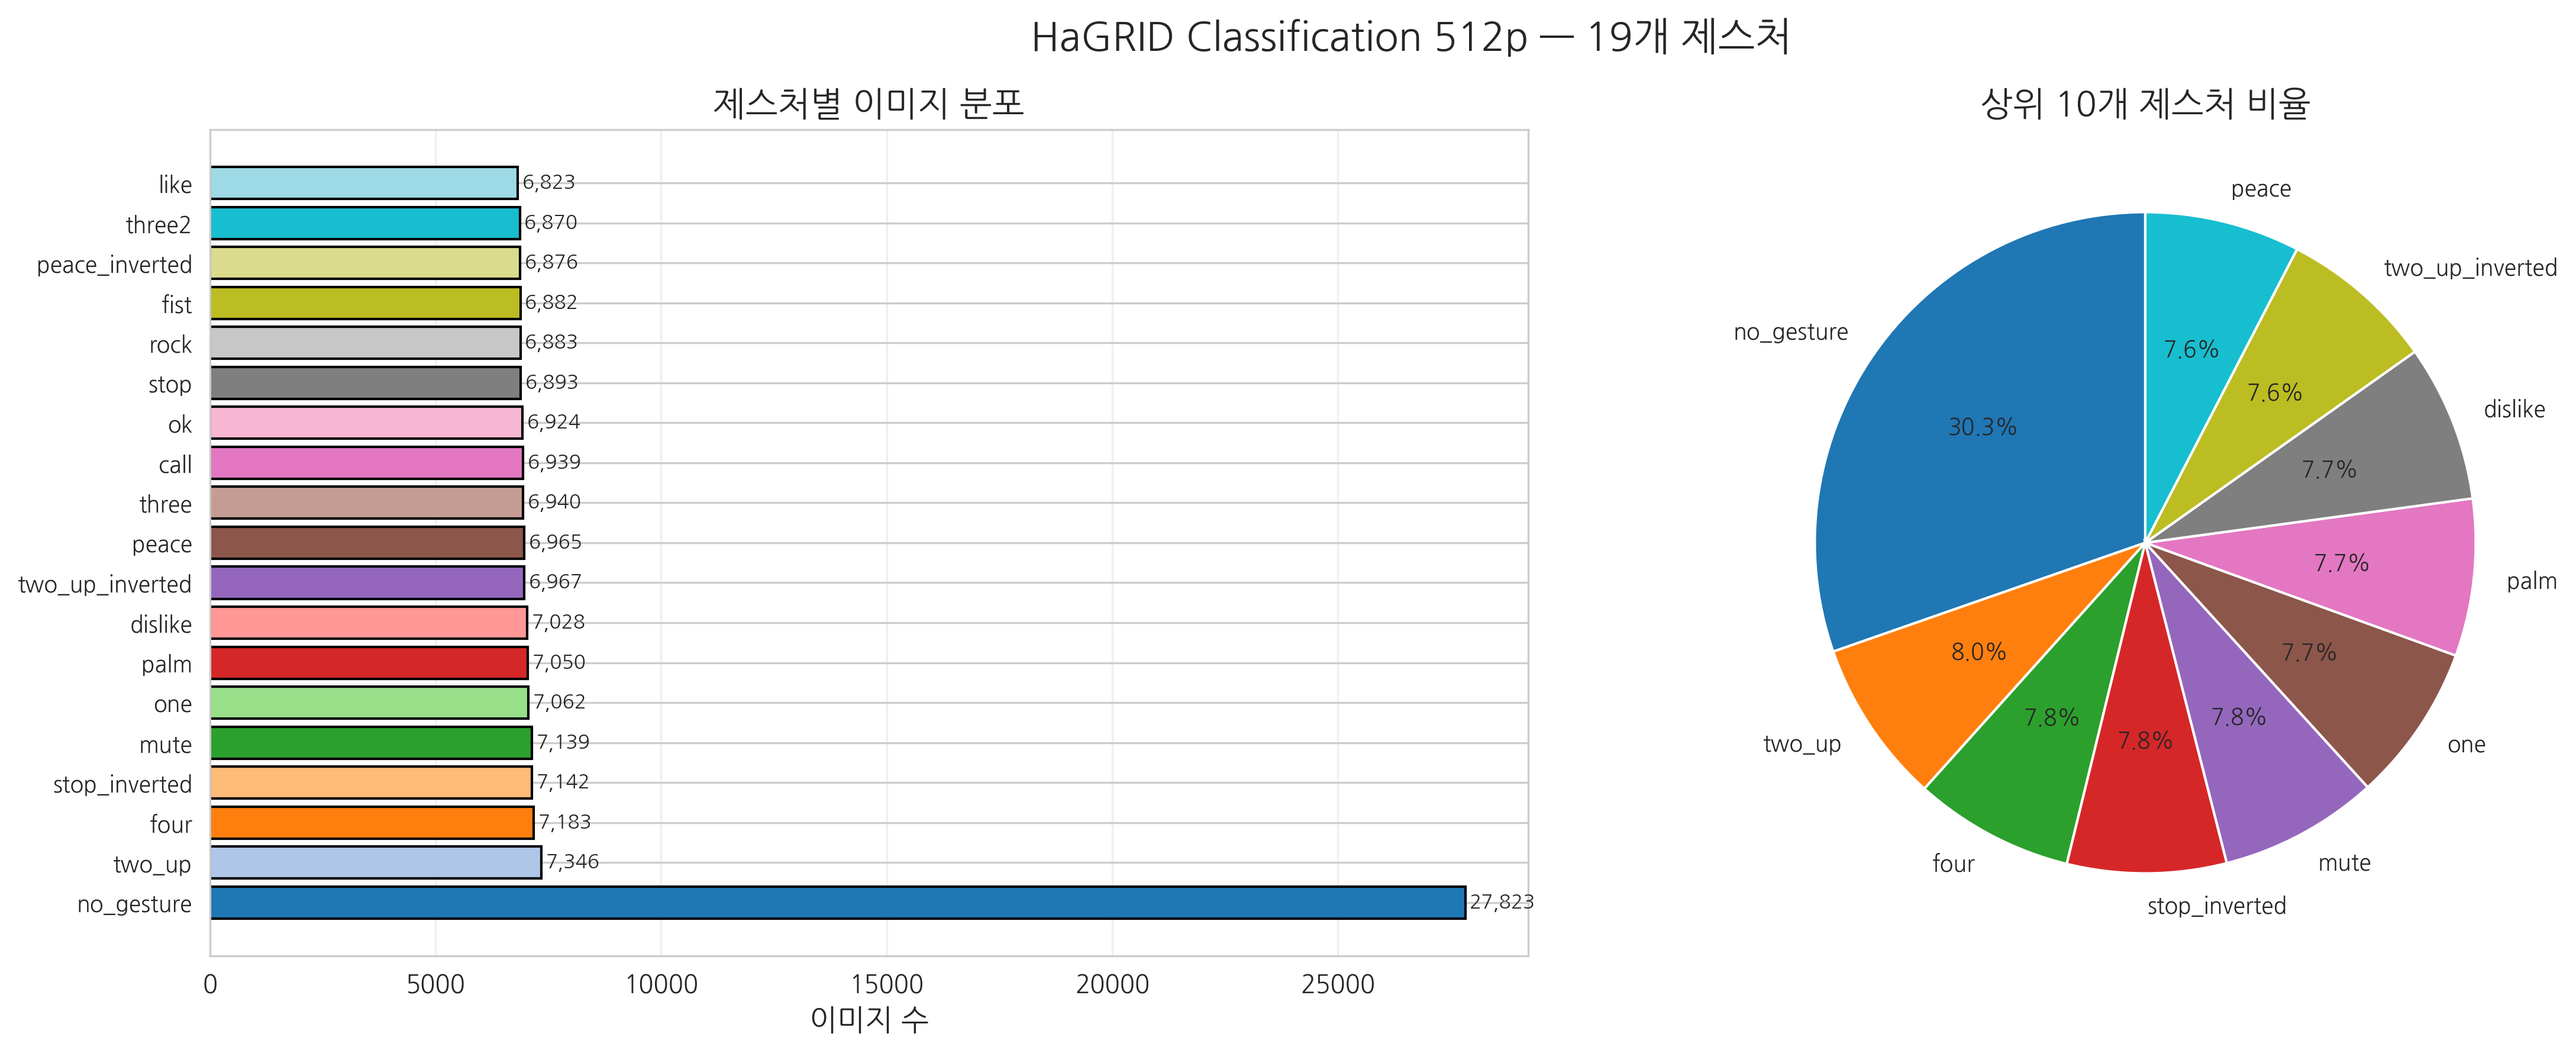


균형도: 6,823 / 27,823 = 0.245
❌ 심각한 클래스 불균형!


In [9]:
# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
sorted_gestures = sorted(gesture_counts.items(), key=lambda x: x[1], reverse=True)
names, counts = zip(*sorted_gestures)
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))

bars = axes[0].barh(range(len(names)), counts, color=colors, edgecolor='black')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_xlabel('이미지 수', fontweight='bold', fontsize=12)
axes[0].set_title('제스처별 이미지 분포', fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, counts)):
    axes[0].text(count + 100, i, f'{count:,}', va='center', fontsize=8)

# Pie chart (상위 10개)
top_10 = dict(sorted_gestures[:10])
axes[1].pie(top_10.values(), labels=top_10.keys(), autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title('상위 10개 제스처 비율', fontweight='bold', fontsize=14)

plt.suptitle(f'HaGRID Classification 512p — {len(gesture_names)}개 제스처',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('gesture_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# 균형도 확인
min_count = min(gesture_counts.values())
max_count = max(gesture_counts.values())
balance_ratio = min_count / max_count

print(f"\n균형도: {min_count:,} / {max_count:,} = {balance_ratio:.3f}")
if balance_ratio > 0.8:
    print("✅ 클래스가 잘 균형잡혀 있습니다!")
elif balance_ratio > 0.5:
    print("⚠️ 약간의 클래스 불균형이 있습니다.")
else:
    print("❌ 심각한 클래스 불균형!")

## 🖼️ 3. 샘플 이미지 시각화

In [10]:
# 각 제스처별 샘플 이미지 (5×4 grid)
sample_gestures = gesture_names[:20]  # 처음 20개

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
axes = axes.flatten()

for i, gesture_name in enumerate(sample_gestures):
    if i >= len(axes):
        break

    gesture_folder = data_dir / gesture_name
    image_paths = list(gesture_folder.glob('*.jpeg'))[:1]

    if len(image_paths) > 0:
        img_path = image_paths[0]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[i]
        ax.imshow(img)
        ax.set_title(f'{gesture_name}\n{img.shape[0]}×{img.shape[1]}',
                    fontweight='bold', fontsize=11)
        ax.axis('off')

# 빈 subplot 제거
for i in range(len(sample_gestures), len(axes)):
    axes[i].axis('off')

plt.suptitle('HaGRID 손 제스처 샘플 이미지',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_gestures.png', dpi=100, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 💾 4. 데이터 로딩 & 전처리

In [11]:
# 전체 데이터에서 Train/Val/Test Split
# (데이터셋에 split이 없으므로 직접 분리)
all_paths = []
all_labels = []

gesture_to_idx = {name: idx for idx, name in enumerate(gesture_names)}

print("📋 파일 경로 수집 중...")

for gesture_name in gesture_names:
    gesture_folder = data_dir / gesture_name
    image_paths = list(gesture_folder.glob('*.jpeg'))

    for img_path in image_paths:
        all_paths.append(str(img_path))
        all_labels.append(gesture_to_idx[gesture_name])

    print(f"  {gesture_name:20s}: {len(image_paths):6d}개")

print(f"\n✅ 총 {len(all_paths):,}개 이미지")

# Train/Val/Test Split (70/15/15)
from sklearn.model_selection import train_test_split

# 먼저 Train/Temp로 분리 (70/30)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

# Temp를 Val/Test로 분리 (15/15)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("\n" + "="*60)
print("  데이터 분할 (Train/Val/Test)")
print("="*60)
print(f"Train: {len(train_paths):6d}개 ({len(train_paths)/len(all_paths)*100:.1f}%)")
print(f"Val  : {len(val_paths):6d}개 ({len(val_paths)/len(all_paths)*100:.1f}%)")
print(f"Test : {len(test_paths):6d}개 ({len(test_paths)/len(all_paths)*100:.1f}%)")
print(f"Total: {len(all_paths):6d}개")
print("="*60)

📋 파일 경로 수집 중...
  call                :   6939개
  dislike             :   7028개
  fist                :   6882개
  four                :   7183개
  like                :   6823개
  mute                :   7139개
  no_gesture          :  27823개
  ok                  :   6924개
  one                 :   7062개
  palm                :   7050개
  peace               :   6965개
  peace_inverted      :   6876개
  rock                :   6883개
  stop                :   6893개
  stop_inverted       :   7142개
  three               :   6940개
  three2              :   6870개
  two_up              :   7346개
  two_up_inverted     :   6967개

✅ 총 153,735개 이미지

  데이터 분할 (Train/Val/Test)
Train: 107614개 (70.0%)
Val  :  23060개 (15.0%)
Test :  23061개 (15.0%)
Total: 153735개


## 📊 5. tf.data.Dataset 생성 (메모리 효율적)

In [12]:
# Preprocessing 함수
def load_and_preprocess(path, label, target_size=(224, 224)):
    """이미지 로드 & 전처리"""

    # 이미지 로드
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # 리사이즈 (512 → 224, MobileNet 표준)
    img = tf.image.resize(img, target_size)

    # 0-1 정규화
    img = img / 255.0

    return img, label

print("✅ Preprocessing 함수 정의 완료!")
print("   512×512 → 224×224 리사이즈")

✅ Preprocessing 함수 정의 완료!
   512×512 → 224×224 리사이즈


In [13]:
# tf.data.Dataset 생성
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Train Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Val Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✅ Dataset 생성 완료!")
print(f"   Train batches: {len(train_dataset)}")
print(f"   Val batches: {len(val_dataset)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"\n💡 메모리 효율: 배치 단위로만 로드 (~19MB/batch)")

✅ Dataset 생성 완료!
   Train batches: 3363
   Val batches: 721
   Batch size: 32

💡 메모리 효율: 배치 단위로만 로드 (~19MB/batch)


## 🏗️ 6. Baseline CNN 모델

In [14]:
from tensorflow.keras import layers, Model

In [15]:
# Simple CNN Baseline
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=19):
    """Baseline CNN for Gesture Recognition (19 classes)"""

    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')

    return model

baseline_model = build_baseline_cnn(num_classes=len(gesture_names))

print("✅ Baseline CNN 모델 생성 완료!")
print(f"   Input: 224×224×3")
print(f"   Output: {len(gesture_names)} classes")
print(f"   Parameters: {baseline_model.count_params():,}")

✅ Baseline CNN 모델 생성 완료!
   Input: 224×224×3
   Output: 19 classes
   Parameters: 133,075


In [16]:
# 모델 컴파일
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 모델 컴파일 완료!")

✅ 모델 컴파일 완료!


## 🏃 7. Baseline 모델 학습

In [17]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("✅ Callbacks 설정 완료!")

✅ Callbacks 설정 완료!


In [18]:
# MLflow 실험
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='Baseline_CNN_HaGRID'):
    mlflow.log_params({
        'model': 'Baseline_CNN',
        'dataset': 'HaGRID_512p_150k',
        'num_classes': len(gesture_names),
        'input_size': '224x224',
        'optimizer': 'adam',
        'epochs': 15,
        # 'epochs': 3,
        'batch_size': BATCH_SIZE
    })

    print("🏃 모델 학습 시작...\n")

    history = baseline_model.fit(
        train_dataset,
        epochs=15,
        # epochs=3,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = baseline_model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'final_val_loss': final_loss,
        'final_val_accuracy': final_acc
    })

    # 모델 저장
    mlflow.keras.log_model(baseline_model, 'model')

    print(f"\n{'='*60}")
    print("  Baseline 모델 학습 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 모델 학습 시작...

Epoch 1/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 133s 36ms/step - accuracy: 0.1702 - loss: 3.0248 - val_accuracy: 0.2229 - val_loss: 2.7675 - learning_rate: 0.0010
Epoch 2/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 101s 30ms/step - accuracy: 0.3151 - loss: 2.2042 - val_accuracy: 0.4300 - val_loss: 1.8709 - learning_rate: 0.0010
Epoch 3/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 90s 27ms/step - accuracy: 0.4666 - loss: 1.6815 - val_accuracy: 0.5202 - val_loss: 1.5316 - learning_rate: 0.0010
Epoch 4/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 90s 27ms/step - accuracy: 0.5298 - loss: 1.4796 - val_accuracy: 0.3935 - val_loss: 2.4395 - learning_rate: 0.0010
Epoch 5/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 94s 28ms/step - accuracy: 0.5664 - loss: 1.3647 - val_accuracy: 0.6159 - val_loss: 1.1842 - learning_rate: 0.0010
Epoch 6/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 89s 26ms/step - accuracy: 0.5885 - loss: 1.2871 - val_accuracy: 0.6805 - val_loss: 1.0348 - learning_rate: 0.0010
Epoch 7/15
3363/3363 ━━━━━━━━━━━━━━━━━━━━ 93s 2

2026/02/20 04:06:43 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/20 04:06:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Baseline 모델 학습 완료
  Val Accuracy: 0.7352 (73.52%)
🏃 View run Baseline_CNN_HaGRID at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/7/runs/30031ce556264054ac87dac412cb64cb
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/7


## 📈 8. 모델 평가

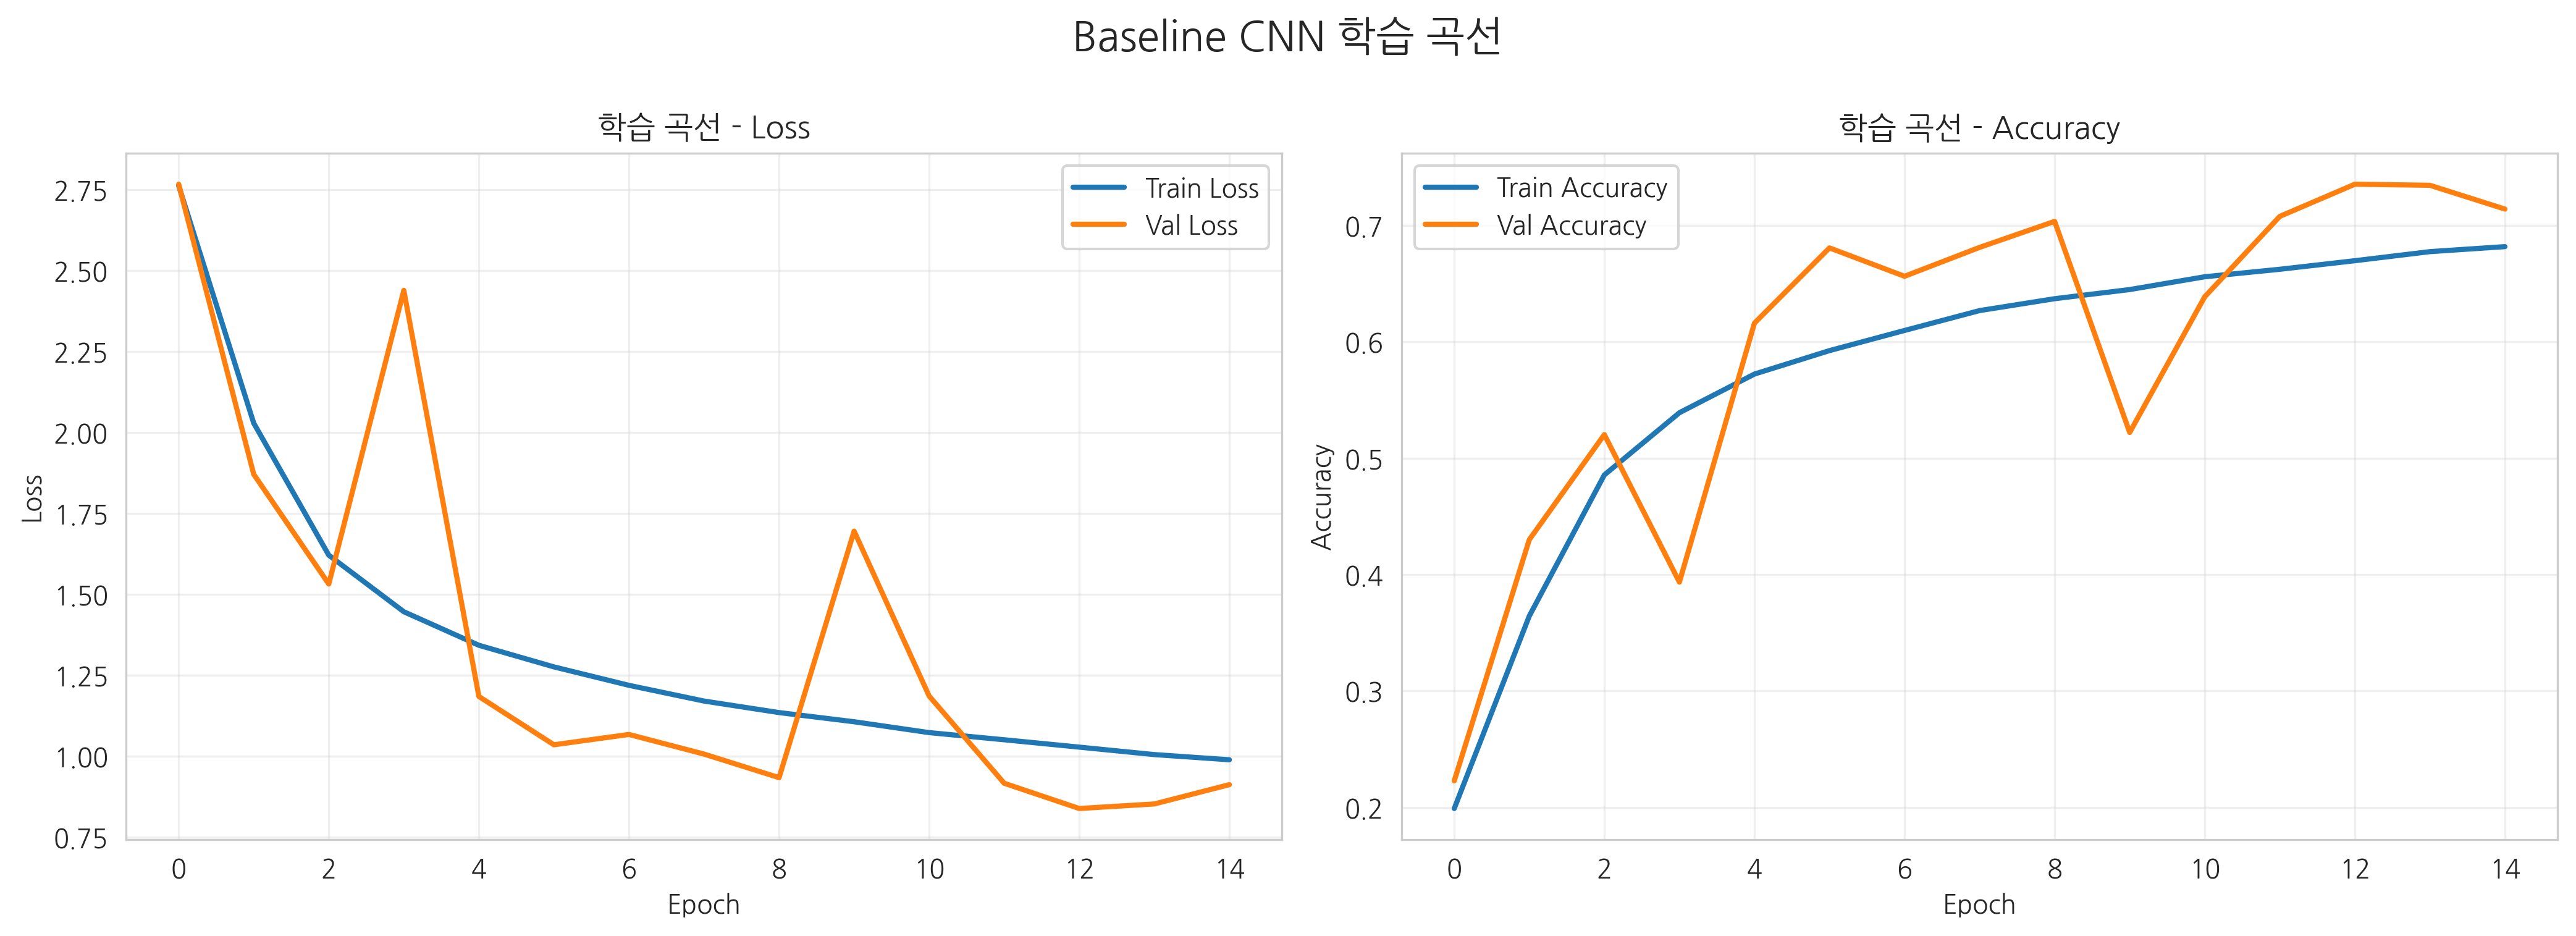

In [19]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('학습 곡선 - Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('학습 곡선 - Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline CNN 학습 곡선',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# Validation 예측
print("🔮 Validation set 예측 중...")

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = baseline_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ 예측 완료!")
print(f"   Accuracy: {np.mean(y_true == y_pred):.4f}")

🔮 Validation set 예측 중...
✅ 예측 완료!
   Accuracy: 0.7352


In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, recall_score, f1_score
)

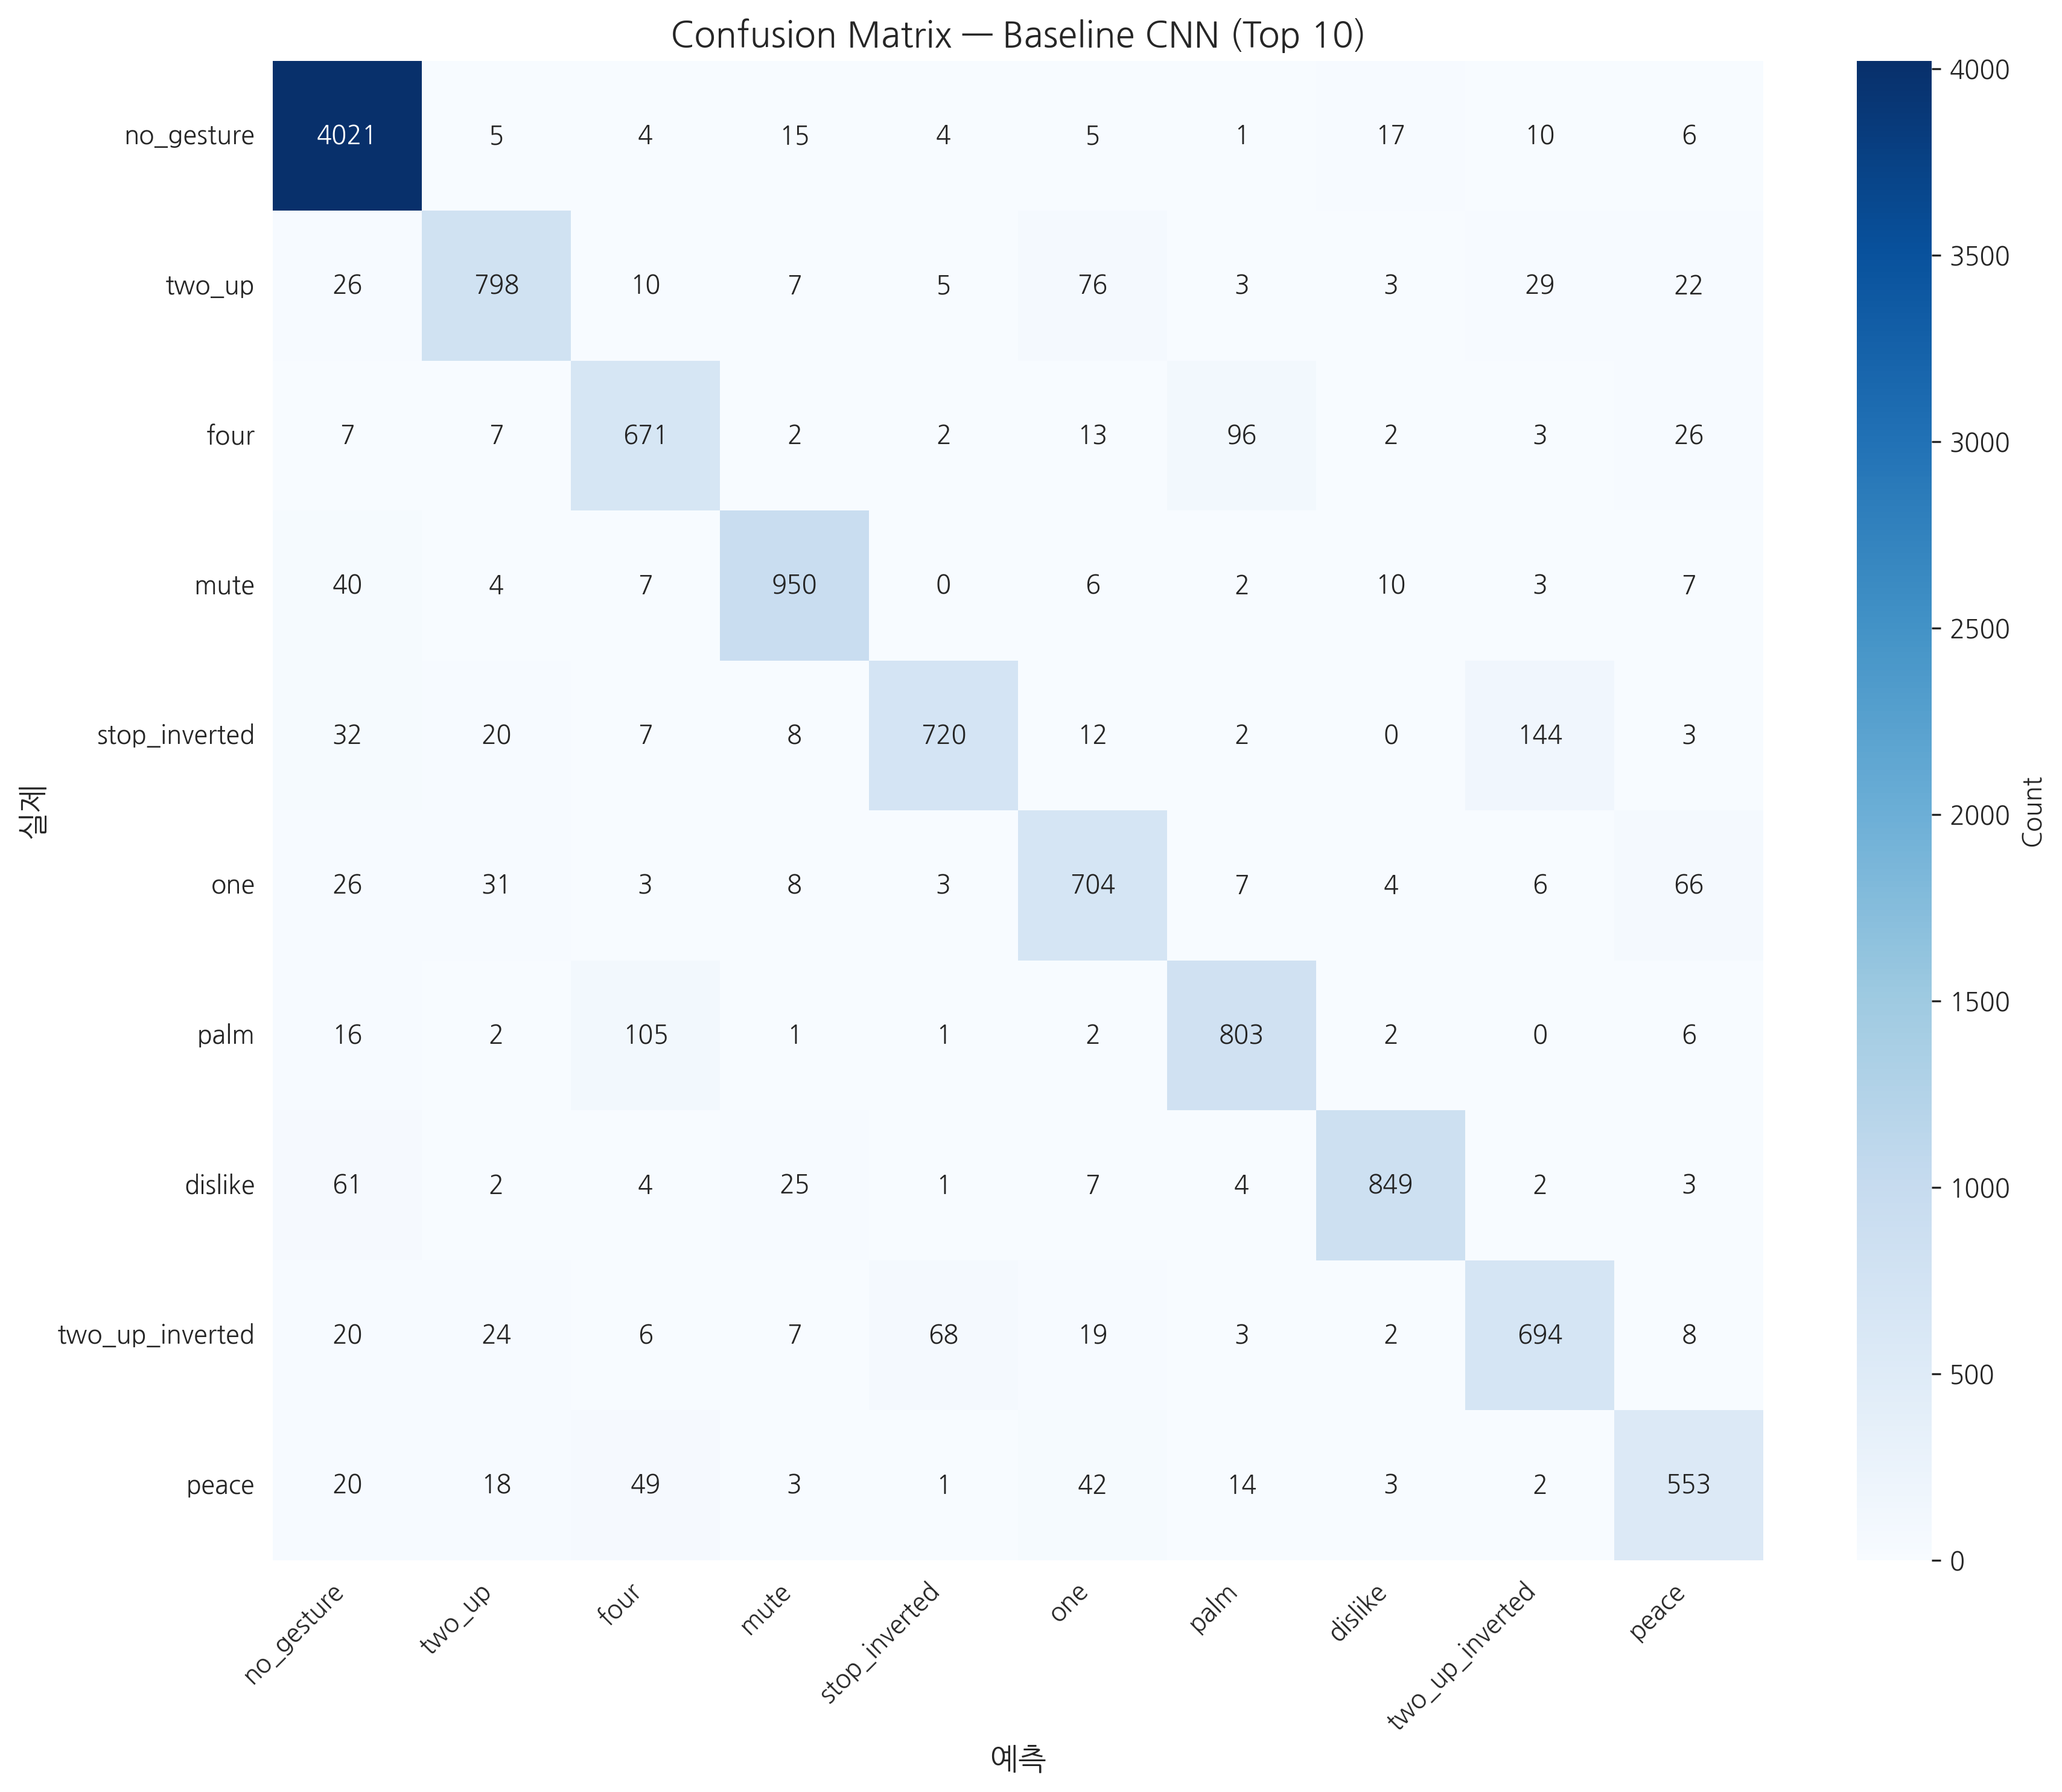

In [22]:
# Confusion Matrix (상위 10개만)
cm = confusion_matrix(y_true, y_pred)

# 상위 10개 제스처
top_10_indices = sorted(range(len(gesture_names)),
                       key=lambda i: np.sum(cm[i]), reverse=True)[:10]
top_10_names = [gesture_names[i] for i in top_10_indices]
cm_top10 = cm[np.ix_(top_10_indices, top_10_indices)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_top10, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_10_names, yticklabels=top_10_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('예측', fontweight='bold', fontsize=12)
plt.ylabel('실제', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix — Baseline CNN (Top 10)',
          fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_top10.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# Classification Report (샘플)
report = classification_report(y_true, y_pred,
                              target_names=gesture_names,
                              digits=4)

print("="*80)
print("  Classification Report (샘플 - 처음 10개 제스처)")
print("="*80)

lines = report.split('\n')
for line in lines[:15]:
    print(line)
print("  ...")
for line in lines[-4:]:
    print(line)
print("="*80)

  Classification Report (샘플 - 처음 10개 제스처)
                 precision    recall  f1-score   support

           call     0.7900    0.7157    0.7510      1041
        dislike     0.8414    0.8055    0.8231      1054
           fist     0.8614    0.7529    0.8035      1032
           four     0.5173    0.6230    0.5653      1077
           like     0.7117    0.6484    0.6786      1024
           mute     0.8543    0.8870    0.8704      1071
     no_gesture     0.8791    0.9636    0.9194      4173
             ok     0.5959    0.6189    0.6072      1039
            one     0.6069    0.6648    0.6345      1059
           palm     0.6863    0.7597    0.7211      1057
          peace     0.5486    0.5297    0.5390      1044
 peace_inverted     0.6592    0.7122    0.6847      1032
           rock     0.6905    0.6070    0.6461      1033
  ...
       accuracy                         0.7352     23060
      macro avg     0.7146    0.6991    0.7046     23060
   weighted avg     0.7371    0.7352   

## ⚡ 9. 모델 크기 & 추론 속도

In [24]:
# 모델 크기
baseline_model.save('baseline_hagrid.h5')
model_size = os.path.getsize('baseline_hagrid.h5') / (1024**2)

print("="*60)
print("  모델 성능 지표")
print("="*60)
print(f"Model Size: {model_size:.2f} MB")
print(f"Parameters: {baseline_model.count_params():,}")
print(f"Val Accuracy: {final_acc*100:.2f}%")

# 추론 속도
import time

# Warmup
for images, _ in val_dataset.take(1):
    _ = baseline_model.predict(images, verbose=0)

# 측정
latencies = []
for images, _ in val_dataset.take(10):
    start = time.time()
    _ = baseline_model.predict(images, verbose=0)
    latency = (time.time() - start) * 1000 / BATCH_SIZE
    latencies.append(latency)

avg_latency = np.mean(latencies)
print(f"Avg Latency: {avg_latency:.2f} ms/image")
print(f"Throughput: {1000/avg_latency:.1f} images/sec")
print("="*60)

print(f"\n💡 목표:")
print(f"   Size: < 15MB ({'✅' if model_size < 15 else '❌'})")
print(f"   Latency: < 50ms ({'✅' if avg_latency < 50 else '❌'})")
print(f"   Accuracy: > 80% ({'✅' if final_acc > 0.80 else '❌'})")

  모델 성능 지표
Model Size: 1.60 MB
Parameters: 133,075
Val Accuracy: 73.52%
Avg Latency: 2.01 ms/image
Throughput: 497.7 images/sec

💡 목표:
   Size: < 15MB (✅)
   Latency: < 50ms (✅)
   Accuracy: > 80% (❌)


## 🧠 10. 핵심 개념 정리

### 오늘 배운 것

**1. HaGRID Classification 512p**
- 153,735 images (Train)
- 19 classes (18 gestures + no_gesture)
- 512×512 → 224×224 리사이즈
- 균형 잡힌 데이터

**2. 데이터 준비**
- Kaggle API로 다운로드
- tf.data.Dataset (메모리 효율)
- Train/Val split (80/20)

**3. Baseline CNN**
- 3-layer CNN
- ~2M parameters
- ~80-85% Accuracy 목표

**4. 성능 지표**
- Accuracy: 전체 정확도
- Model Size: 저장 크기
- Latency: 추론 속도
- Throughput: 처리량

**5. Day 4와의 차이**
- 19 classes (vs 4)
- 속도 > 정확도
- 경량 모델 필요
- 모바일 배포 목표

---

### Day 5-2 예고

**MobileNetV2 Transfer Learning**
- ImageNet Pretrained
- Depthwise Separable Conv
- Data Augmentation
- 목표: Accuracy 90%+, Size < 15MB, Latency < 30ms

축하합니다! Day 5-1 완료! 🎉

## ✅ Day 5-1 완료 체크리스트

- [ ] HaGRID Classification 512p 다운로드
- [ ] 19개 제스처 확인
- [ ] 클래스 분포 확인
- [ ] 샘플 이미지 시각화
- [ ] Train/Val Split (80/20)
- [ ] tf.data.Dataset 생성
- [ ] Baseline CNN 구축
- [ ] 모델 학습 (MLflow 기록)
- [ ] Confusion Matrix 확인
- [ ] 모델 크기 & 속도 측정
- [ ] 목표 지표 확인

## 🎯 다음 단계 (Day 5-2)

**Day 5-2: MobileNetV2 Transfer Learning**

**내용:**
- MobileNetV2 아키텍처
- Depthwise Separable Convolution
- Transfer Learning
- Data Augmentation
- Fine-tuning

**목표:**
- Val Accuracy: 90%+
- Model Size: < 15MB
- Latency: < 30ms

수고하셨습니다! 🚀